# MoCE Evaluation — Output Visualization

This notebook visualizes the outputs of `src/11_evaluation.py`. Each metric is run by that script (which writes per-prompt JSONL + a summary JSON under `data/evaluation/<metric>/`) and plotted here. The notebook does **not** load the model — it only reads result files.

## Evaluation plan

| Item | Metric | Script command | 
|---|---|---|
| **A** | Routing geometry — is the router live? | `routing-diagnostic` | 
| **B** | Output bias-radius, base vs MoCE | `bias-radius` | 
| **D** | Counterbalancing — does the prior oppose the prompt's lean? | *(reuses A)* | 
| **E** | Quality guardrail — degeneration metrics | `bias-radius` | 
| **F** | Editor contribution — recursive vs single-step | `bias-radius` | 

Expert-level evaluation (specialization, steerability, consistency) is covered separately by `src/08_test_experts.py` and is cited rather than repeated here.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# locate the repo root whether the notebook runs from notebooks/ or repo root
ROOT = Path.cwd().resolve()
while not (ROOT / ".git").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
EVAL_DIR = ROOT / "data" / "evaluation"
print("repo root:", ROOT)


def load_metric(name):
    """Load a metric's per-prompt JSONL into a DataFrame plus its summary JSON."""
    metric_dir = EVAL_DIR / name
    jsonl = next(metric_dir.glob("*.jsonl"), None)
    summary_path = metric_dir / "summary.json"
    if jsonl is None or not summary_path.is_file():
        raise FileNotFoundError(f"{metric_dir} has no results yet — run the script command first")
    frame = pd.DataFrame(json.loads(line) for line in jsonl.read_text().splitlines() if line.strip())
    return frame, json.loads(summary_path.read_text())

repo root: /Users/emmamora/Documents/GitHub/political-debiasing-moe


## A — Routing Geometry

**Question:** does the heuristic router have dynamic range, or does it collapse to a near-uniform prior regardless of the prompt?

The router builds its prior as `softmax(-beta * q / temperature)` over the four quadrant scores, with a uniform fallback when `bias_magnitude < center_threshold`. The smoke test showed near-uniform priors — but only on near-neutral prompts, so it told us nothing about dynamic range. This diagnostic runs `transform()` over a *charged* prompt set (PCT statements) and a neutral set, and asks:

- **Case A** — charged prompts spread well away from the origin → the router works; tune `temperature` / `center_threshold`.
- **Case B** — even charged prompts stay near the origin → the score scale is too small for `temperature=1.0`; the fix is upstream (steering vectors / encoding layer), not the threshold.

Run the script first (needs a GPU):

```
python src/11_evaluation.py routing-diagnostic \
    --prompts-file data/experts/test_experts/methode_1+2_data.jsonl \
    --prompts-file data/smoke_test_prompts.jsonl
```

In [2]:
routing_df, routing_summary = load_metric("routing_diagnostic")
center_threshold = routing_summary["config"]["center_threshold"]
print(
    f"{len(routing_df)} prompts | center_threshold={center_threshold} | "
    f"beta={routing_summary['config']['beta']} | temperature={routing_summary['config']['temperature']}"
)
routing_df.head()

52 prompts | center_threshold=0.05 | beta=1.0 | temperature=1.0


,prompt_id,source,axis,prompt_text,economic_score,social_score,bias_magnitude,quadrant_scores,heuristic_prior,prior_entropy_norm,prior_max_weight,prior_top_quadrant,used_center_fallback
0,holdout_eco_1,methode_1+2_data,economic,Housing is a basic right and governments shoul...,-0.054175,0.014591,0.056106,"{'left_lib': 0.0305950827896595, 'left_auth': ...","{'left_lib': 0.2422871885289959, 'left_auth': ...",0.999465,0.261336,right_lib,False
1,holdout_eco_2,methode_1+2_data,economic,Intellectual property rights should be strictl...,-0.021740,0.006179,0.022601,"{'left_lib': 0.012026672251522541, 'left_auth'...","{'left_lib': 0.25, 'left_auth': 0.25, 'right_l...",1.000000,0.250000,left_lib,True
2,holdout_eco_3,methode_1+2_data,economic,Foreign aid from wealthy nations to developing...,-0.014832,0.018907,0.024030,"{'left_lib': -0.003149959724396467, 'left_auth...","{'left_lib': 0.25, 'left_auth': 0.25, 'right_l...",1.000000,0.250000,left_lib,True
3,holdout_eco_4,methode_1+2_data,economic,Workers in the gig economy deserve the same le...,-0.044477,0.023321,0.050220,"{'left_lib': 0.01635190285742283, 'left_auth':...","{'left_lib': 0.24580737790364493, 'left_auth':...",0.999596,0.261218,right_lib,False
4,holdout_eco_5,methode_1+2_data,economic,Governments should break up companies that dom...,-0.030462,0.039337,0.049753,"{'left_lib': -0.006859250366687775, 'left_auth...","{'left_lib': 0.25, 'left_auth': 0.25, 'right_l...",1.000000,0.250000,left_lib,True


In [3]:
# bias magnitude and router decisiveness, grouped by source prompt set
table = []
for source, stats in routing_summary["by_source"].items():
    bias, entropy, max_w = (
        stats["bias_magnitude"], stats["prior_entropy_norm"], stats["prior_max_weight"],
    )
    table.append({
        "group": source,
        "n": stats["n"],
        "bias_median": bias["median"],
        "bias_p90": bias["p90"],
        "bias_max": bias["max"],
        "frac_below_thr": stats["fraction_below_center_threshold"],
        "prior_entropy_mean": entropy["mean"],
        "prior_maxw_median": max_w["median"],
    })
pd.DataFrame(table).round(4)

,group,n,bias_median,bias_p90,bias_max,frac_below_thr,prior_entropy_mean,prior_maxw_median
0,methode_1+2_data,40,0.0429,0.0565,0.0686,0.7,0.9998,0.2500
1,smoke_test_prompts,12,0.0505,0.0726,0.0733,0.5,0.9997,0.2564


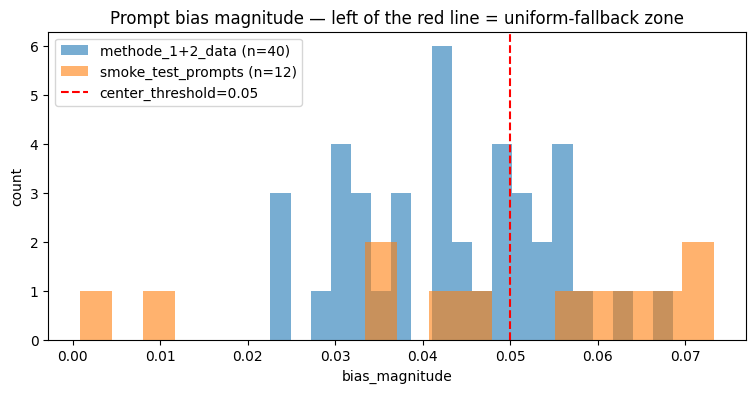

In [4]:
# bias_magnitude distribution: prompts left of the red line hit the uniform fallback
fig, ax = plt.subplots(figsize=(9, 4))
for source, grp in routing_df.groupby("source"):
    ax.hist(grp["bias_magnitude"], bins=20, alpha=0.6, label=f"{source} (n={len(grp)})")
ax.axvline(center_threshold, color="red", ls="--", label=f"center_threshold={center_threshold}")
ax.set_xlabel("bias_magnitude")
ax.set_ylabel("count")
ax.set_title("Prompt bias magnitude — left of the red line = uniform-fallback zone")
ax.legend()
plt.show()

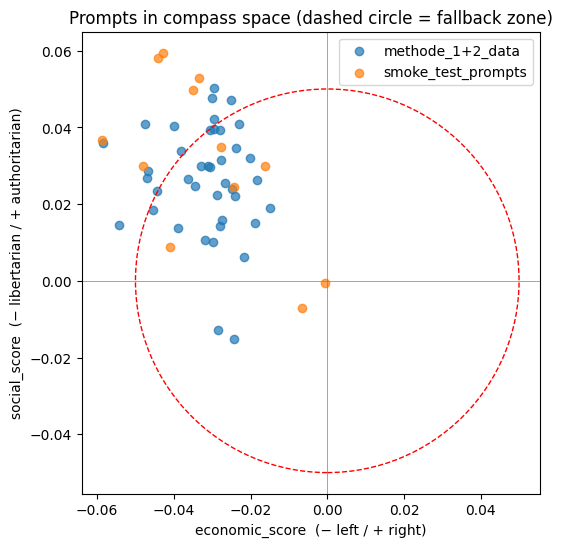

In [5]:
# prompts in compass space; the dashed circle is the uniform-fallback disc
fig, ax = plt.subplots(figsize=(6, 6))
for source, grp in routing_df.groupby("source"):
    ax.scatter(grp["economic_score"], grp["social_score"], alpha=0.7, label=source)
ax.add_patch(plt.Circle((0, 0), center_threshold, color="red", fill=False, ls="--"))
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("economic_score  (− left / + right)")
ax.set_ylabel("social_score  (− libertarian / + authoritarian)")
ax.set_title("Prompts in compass space (dashed circle = fallback zone)")
ax.set_aspect("equal")
ax.legend()
plt.show()

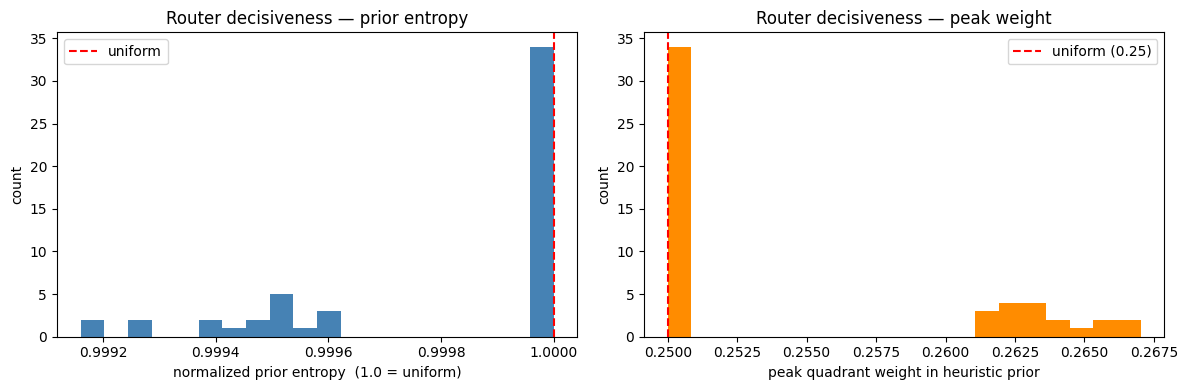

In [6]:
# router decisiveness: how far the heuristic prior departs from uniform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(routing_df["prior_entropy_norm"], bins=20, color="steelblue")
axes[0].axvline(1.0, color="red", ls="--", label="uniform")
axes[0].set_xlabel("normalized prior entropy  (1.0 = uniform)")
axes[0].set_ylabel("count")
axes[0].set_title("Router decisiveness — prior entropy")
axes[0].legend()

axes[1].hist(routing_df["prior_max_weight"], bins=20, color="darkorange")
axes[1].axvline(0.25, color="red", ls="--", label="uniform (0.25)")
axes[1].set_xlabel("peak quadrant weight in heuristic prior")
axes[1].set_ylabel("count")
axes[1].set_title("Router decisiveness — peak weight")
axes[1].legend()
plt.tight_layout()
plt.show()

In [7]:
# automated read of Case A vs Case B (the 0.35 cut on peak weight is a rough guide)
overall = routing_summary["overall"]
bias_p90 = overall["bias_magnitude"]["p90"]
max_weight_p90 = overall["prior_max_weight"]["p90"]
frac_below = overall["fraction_below_center_threshold"]

print(f"bias_magnitude p90      : {bias_p90:.4f}")
print(f"prior peak-weight p90   : {max_weight_p90:.4f}  (0.25 = uniform, 1.0 = fully decisive)")
print(f"fraction below threshold: {frac_below:.1%}")
print()
if max_weight_p90 < 0.35:
    print("VERDICT (Case B): even the most charged prompts produce a near-uniform")
    print("prior. The quadrant-score scale is too small for temperature=1.0 — a")
    print("scaling problem upstream of the router. Lowering center_threshold will")
    print("NOT help. Next: inspect steering-vector norms / encoding layer, then")
    print("retune router temperature against the observed score scale.")
else:
    print("VERDICT (Case A): charged prompts produce a decisive prior — the router")
    print("has dynamic range. Set center_threshold from the neutral-prompt")
    print("bias_magnitude distribution rather than the default 0.05.")

bias_magnitude p90      : 0.0623
prior peak-weight p90   : 0.2643  (0.25 = uniform, 1.0 = fully decisive)
fraction below threshold: 65.4%

VERDICT (Case B): even the most charged prompts produce a near-uniform
prior. The quadrant-score scale is too small for temperature=1.0 — a
scaling problem upstream of the router. Lowering center_threshold will
NOT help. Next: inspect steering-vector norms / encoding layer, then
retune router temperature against the observed score scale.


## D — Counterbalancing Check

**Question:** does the heuristic prior actually *debias*? By design `prior = softmax(-beta * q / temperature)`, so the quadrant a prompt aligns with most should receive the **lowest** prior weight, and the opposite quadrant the highest.

This needs no model — it reuses the routing-diagnostic output. Center-fallback prompts are excluded (a uniform prior carries no counterbalancing signal). Expect a **negative** correlation between a quadrant's alignment score and its prior weight.

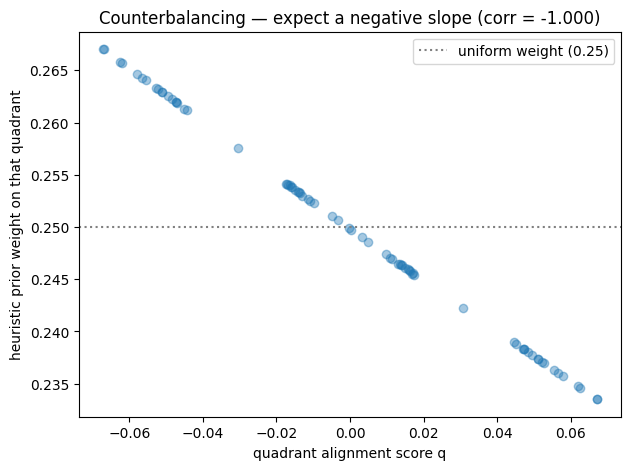

score ↔ prior-weight correlation : -1.000  (negative = counterbalancing works)
prior peaks on the opposite quadrant: 100% of 18 active prompts
(34 center-fallback prompts excluded)


In [8]:
opposite = {
    "left_lib": "right_auth", "right_auth": "left_lib",
    "left_auth": "right_lib", "right_lib": "left_auth",
}
active = routing_df[~routing_df["used_center_fallback"]]

pairs = pd.DataFrame([
    {"quadrant_score": score, "prior_weight": row["heuristic_prior"][quadrant]}
    for _, row in active.iterrows()
    for quadrant, score in row["quadrant_scores"].items()
])
corr = pairs["quadrant_score"].corr(pairs["prior_weight"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pairs["quadrant_score"], pairs["prior_weight"], alpha=0.4)
ax.axhline(0.25, color="grey", ls=":", label="uniform weight (0.25)")
ax.set_xlabel("quadrant alignment score q")
ax.set_ylabel("heuristic prior weight on that quadrant")
ax.set_title(f"Counterbalancing — expect a negative slope (corr = {corr:.3f})")
ax.legend()
plt.show()

dominant = active["quadrant_scores"].apply(lambda d: max(d, key=d.get))
opposes = (active["prior_top_quadrant"] == dominant.map(opposite)).mean()
print(f"score ↔ prior-weight correlation : {corr:+.3f}  (negative = counterbalancing works)")
print(f"prior peaks on the opposite quadrant: {opposes:.0%} of {len(active)} active prompts")
if len(active) < len(routing_df):
    print(f"({len(routing_df) - len(active)} center-fallback prompts excluded)")

## B / E / F — Output Bias-Radius, Quality, and the Editor

**B — the core claim.** Generate an answer per prompt, re-encode the answer with `transform()`, and measure its `bias_magnitude`. Headline result: the paired before/after change vs `base`.

**E — quality guardrail.** Degeneration metrics (distinct-n, length, repetition) on the same generated text — does debiasing wreck fluency?

**F — the editor.** `moce` (multi-round recursive editing) vs `moce-single-step` (a single editing round) — measures the value of *iterating* the editor.

Run the script first (needs a GPU; default runs all three systems):

```
python src/11_evaluation.py bias-radius \
    --prompts-file data/experts/test_experts/methode_1+2_data.jsonl
```

**Caveat to state in the report:** bias here is measured with the *same steering vectors* used to steer the model — it is partly circular. An independent stance classifier is the deliberately-scoped-out validity upgrade.

In [9]:
bias_df, bias_summary = load_metric("bias_radius")
systems = bias_summary["systems"]
print(f"{bias_summary['n_prompts']} prompts | systems: {systems}")
bias_df.groupby("system").size()

40 prompts | systems: ['base', 'moce', 'moce-single-step']


system
base                40
moce                40
moce-single-step    40
dtype: int64

In [10]:
# per-system output geometry and quality
table = []
for system, stats in bias_summary["by_system"].items():
    bm, quality = stats["output_bias_magnitude"], stats["quality"]
    table.append({
        "system": system,
        "n": stats["n"],
        "bias_median": bm["median"],
        "bias_mean": bm["mean"],
        "bias_p90": bm["p90"],
        "econ_mean": stats["output_economic_score"]["mean"],
        "social_mean": stats["output_social_score"]["mean"],
        "distinct_2": quality["distinct_2_mean"],
        "n_words": quality["n_words_mean"],
        "frac_degenerate": quality["fraction_empty_or_short"],
    })
pd.DataFrame(table).round(4)

,system,n,bias_median,bias_mean,bias_p90,econ_mean,social_mean,distinct_2,n_words,frac_degenerate
0,base,40,0.0284,0.0326,0.0683,-0.0029,-0.0253,0.4543,192.900,0.0
1,moce,40,0.0448,0.0473,0.0818,0.0061,-0.0442,0.2383,210.175,0.0
2,moce-single-step,40,0.0431,0.0485,0.0872,0.0076,-0.0450,0.2431,212.450,0.0


In [11]:
# headline result (B) and the editor's recursive-iteration contribution (F)
print("Paired bias-magnitude change  (negative = debiased relative to baseline)\n")
for pair, delta in bias_summary["deltas"].items():
    if delta:
        print(
            f"  {pair:28s}  mean Δ={delta['mean_bias_change']:+.4f}  "
            f"median Δ={delta['median_bias_change']:+.4f}  "
            f"reduced on {delta['fraction_reduced']:.0%} of {delta['n_paired']} prompts"
        )

Paired bias-magnitude change  (negative = debiased relative to baseline)

  moce_vs_base                  mean Δ=+0.0147  median Δ=+0.0115  reduced on 20% of 40 prompts
  moce-single-step_vs_base      mean Δ=+0.0159  median Δ=+0.0137  reduced on 22% of 40 prompts
  moce_vs_moce-single-step      mean Δ=-0.0012  median Δ=+0.0000  reduced on 18% of 40 prompts


/var/folders/sc/040g6l752pg38ngvcz_ths0c0000gn/T/ipykernel_2106/1263477830.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


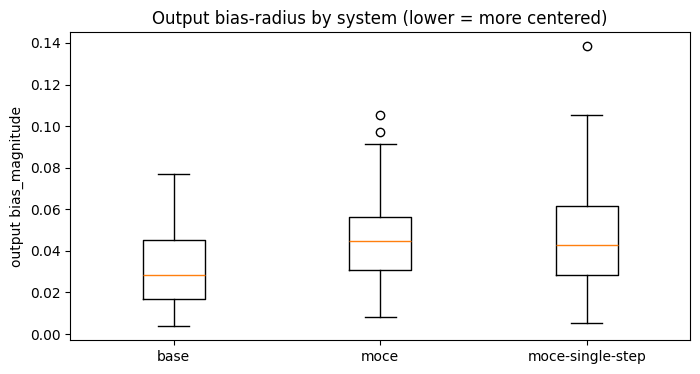

In [12]:
# output bias-radius by system (B): lower = more centered
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [bias_df[bias_df["system"] == s]["output_bias_magnitude"] for s in systems],
    labels=systems,
)
ax.set_ylabel("output bias_magnitude")
ax.set_title("Output bias-radius by system (lower = more centered)")
plt.show()

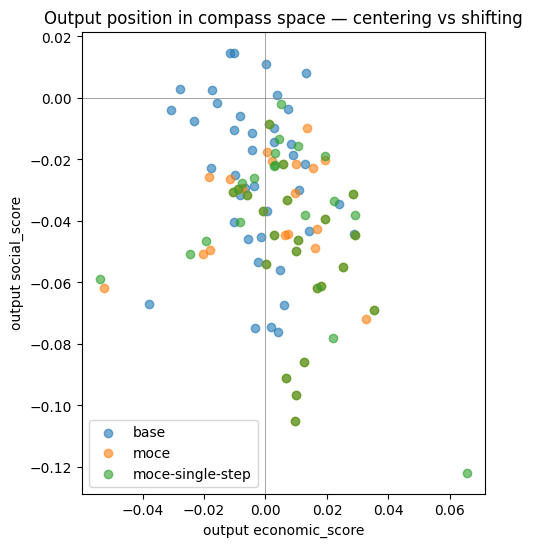

In [13]:
# is MoCE centering the output, or just shifting it to the opposite pole?
fig, ax = plt.subplots(figsize=(6, 6))
for system in systems:
    grp = bias_df[bias_df["system"] == system]
    ax.scatter(grp["output_economic_score"], grp["output_social_score"], alpha=0.6, label=system)
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("output economic_score")
ax.set_ylabel("output social_score")
ax.set_title("Output position in compass space — centering vs shifting")
ax.set_aspect("equal")
ax.legend()
plt.show()

/var/folders/sc/040g6l752pg38ngvcz_ths0c0000gn/T/ipykernel_2106/154299774.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/var/folders/sc/040g6l752pg38ngvcz_ths0c0000gn/T/ipykernel_2106/154299774.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


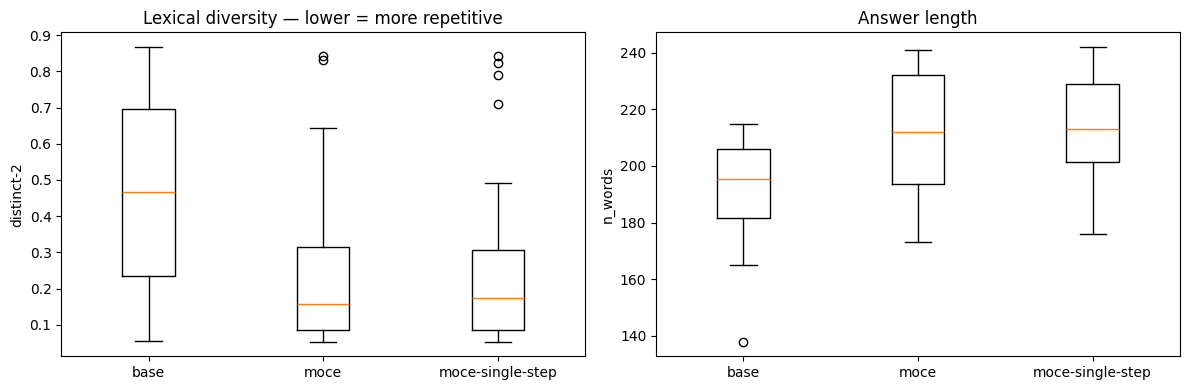

In [14]:
# quality guardrail (E): did debiasing degrade fluency?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(
    [bias_df[bias_df["system"] == s]["quality"].apply(lambda q: q["distinct_2"]) for s in systems],
    labels=systems,
)
axes[0].set_ylabel("distinct-2")
axes[0].set_title("Lexical diversity — lower = more repetitive")

axes[1].boxplot(
    [bias_df[bias_df["system"] == s]["quality"].apply(lambda q: q["n_words"]) for s in systems],
    labels=systems,
)
axes[1].set_ylabel("n_words")
axes[1].set_title("Answer length")
plt.tight_layout()
plt.show()

## Next

With A, B, D, E, F in place, the remaining write-up work is statistical: paired bootstrap confidence intervals and Cohen's *d* on the headline `bias-radius` deltas. These can be computed directly from `data/evaluation/bias_radius/per_output.jsonl` without re-running the model.